<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/ModelosRegressao/Regress%C3%A3o_multinominaL_analise_multinomial_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Regressão Multinomial com Gráficos

## Modelo Construído
Foi ajustado um modelo de **regressão logística multinomial** para investigar os fatores que influenciam a escolha do tipo de programa escolar (**prog**) pelos alunos.  

- **Variável dependente**: `prog` (categorias: *general*, *academic*, *vocation*).  
- **Categoria de referência**: *general*.  
- **Variáveis independentes**:  
  - `ses` (status socioeconômico, referência = *low*).  
  - `write` (nota de escrita).  

---

## Resultados Principais

### Comparação: *Academic vs General*
- **SES High**: aumenta significativamente a chance de estar em programa acadêmico.  
- **Write**: cada ponto adicional aumenta a probabilidade de estar em programa acadêmico.  

### Comparação: *Vocation vs General*
- **Write**: notas mais altas reduzem a chance de estar em programa vocacional.  
- **SES**: não mostrou efeito significativo.  

---

## Gráficos de Apoio

### Odds Ratios Estimados
![odds ratios](odds_ratios_plot.png)

### Probabilidade Prevista de Academic por SES
![probabilidades previstas](probabilidades_previstas_plot.png)

---

## Conclusões
1. **SES alto** e **boas notas de escrita** favorecem o ingresso em programas acadêmicos.  
2. **Notas mais baixas de escrita** aumentam a propensão a programas vocacionais.  
3. O modelo é estatisticamente significativo e fornece evidências sobre como SES e Write afetam a escolha de programa.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats


In [2]:
from google.colab import files
uploaded = files.upload()

# Substitua pelo nome correto do seu arquivo
df = pd.read_csv("dados_lista_2_multinominal-1.csv")

# Ajustar categorias
df["prog"] = pd.Categorical(df["prog"], categories=["general", "academic", "vocation"])
df["ses"] = pd.Categorical(df["ses"], categories=["low", "middle", "high"])

# Subconjunto para modelo
df_model = df.dropna(subset=["prog", "ses", "write"]).copy()
df.head()


Saving dados_lista_2_multinominal-1.csv to dados_lista_2_multinominal-1 (1).csv


,Unnamed: 0,id,female,ses,schtyp,prog,read,write,math,science,socst,honors,awards,cid
0,1,45,female,low,public,vocation,34,35,41,29,26,not enrolled,0,1
1,2,108,male,middle,public,general,34,33,41,36,36,not enrolled,0,1
2,3,15,male,high,public,vocation,39,39,44,26,42,not enrolled,0,1
3,4,67,male,low,public,vocation,37,37,42,33,32,not enrolled,0,1
4,5,153,male,middle,public,vocation,39,31,40,39,51,not enrolled,0,1


## 2) Análise Descritiva

In [3]:
print("=== Frequências ===")
for col in ["prog", "ses", "female", "schtyp"]:
    if col in df.columns:
        print(f"\n{col}:\n", df[col].value_counts())

print("\n=== Estatísticas descritivas ===")
print(df[["write", "read", "math"]].describe())

# Crosstab e qui-quadrado
ct = pd.crosstab(df["prog"], df["ses"])
print("\nCrosstab prog x ses:\n", ct)
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"\nQui-quadrado: {chi2:.3f}, gl={dof}, p={p:.4f}")


=== Frequências ===

prog:
 prog
academic    105
vocation     50
general      45
Name: count, dtype: int64

ses:
 ses
middle    95
high      58
low       47
Name: count, dtype: int64

female:
 female
female    109
male       91
Name: count, dtype: int64

schtyp:
 schtyp
public     168
private     32
Name: count, dtype: int64

=== Estatísticas descritivas ===
            write        read        math
count  200.000000  200.000000  200.000000
mean    52.775000   52.230000   52.645000
std      9.478586   10.252937    9.368448
min     31.000000   28.000000   33.000000
25%     45.750000   44.000000   45.000000
50%     54.000000   50.000000   52.000000
75%     60.000000   60.000000   59.000000
max     67.000000   76.000000   75.000000

Crosstab prog x ses:
 ses       low  middle  high
prog                       
general    16      20     9
academic   19      44    42
vocation   12      31     7

Qui-quadrado: 16.604, gl=4, p=0.0023


## 3) Gráficos

/tmp/ipython-input-1136822753.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["ses", "prog"]).size().unstack(fill_value=0)


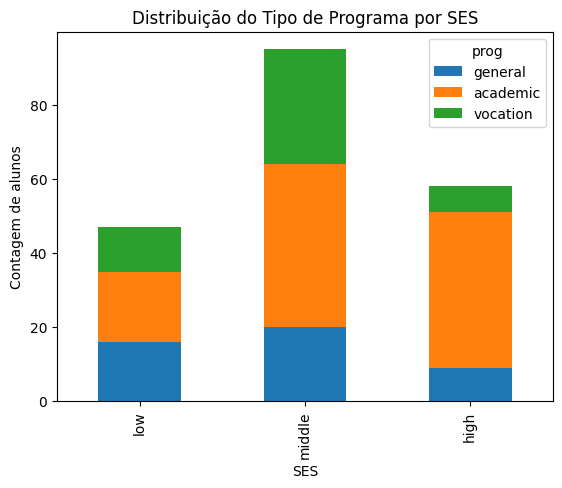

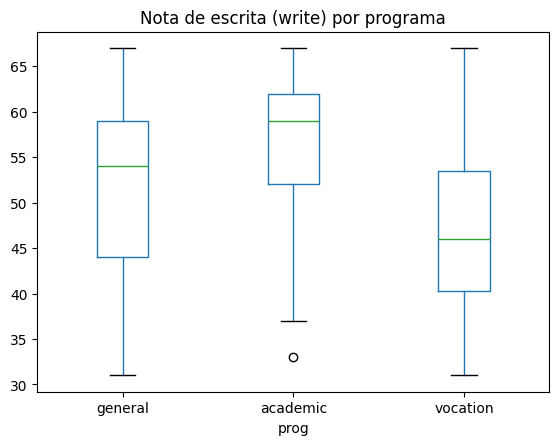

In [4]:
# Distribuição de programas por SES
counts = df.groupby(["ses", "prog"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True)
plt.title("Distribuição do Tipo de Programa por SES")
plt.xlabel("SES")
plt.ylabel("Contagem de alunos")
plt.show()

# Boxplot de write por programa
df.boxplot(column="write", by="prog", grid=False)
plt.title("Nota de escrita (write) por programa")
plt.suptitle("")
plt.show()


## 4) Modelo Multinomial (prog ~ ses + write)

In [5]:
y = df_model["prog"].cat.codes
X = pd.concat([
    pd.get_dummies(df_model["ses"], drop_first=True, prefix="ses"),
    df_model[["write"]]
], axis=1)
X = sm.add_constant(X)

# Convert boolean columns to integers
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

model = sm.MNLogit(y, X)
res = model.fit(method="newton", disp=0)
print(res.summary())

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  200
Model:                        MNLogit   Df Residuals:                      192
Method:                           MLE   Df Model:                            6
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.1182
Time:                        19:38:47   Log-Likelihood:                -179.98
converged:                       True   LL-Null:                       -204.10
Covariance Type:            nonrobust   LLR p-value:                 1.063e-08
       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8522      1.166     -2.445      0.014      -5.138      -0.566
ses_middle     0.5333      0.444      1.202      0.229      -0.336       1.403
ses_high       1.1628      0.514      2.261      0.0

## 5) Odds Ratios com IC95% (corrigido)

In [6]:
params = res.params
pvals = res.pvalues
ci = res.conf_int()

rows = []
mapping = {0: "1", 1: "2"}  # map colunas -> índice de conf_int

for eq in params.columns:  # 0=academic vs general, 1=vocation vs general
    comp = "academic vs general" if eq == 0 else "vocation vs general"
    eq_key = mapping[eq]
    for var in params.index:
        if var == "const":
            continue
        beta = params.loc[var, eq]
        lo = ci.loc[(eq_key, var), "lower"]
        hi = ci.loc[(eq_key, var), "upper"]
        p = pvals.loc[var, eq]
        rows.append([comp, var, np.exp(beta), np.exp(lo), np.exp(hi), p])

or_df = pd.DataFrame(rows, columns=["Comparação", "Variável", "OR", "IC95_lo", "IC95_hi", "p_valor"])
or_df


,Comparação,Variável,OR,IC95_lo,IC95_hi,p_valor
0,academic vs general,ses_middle,1.704533,0.714332,4.067343,0.229429
1,academic vs general,ses_high,3.198980,1.167635,8.764273,0.023737
2,academic vs general,write,1.059639,1.016092,1.105053,0.006819
3,vocation vs general,ses_middle,2.281160,0.872896,5.961412,0.092451
4,vocation vs general,ses_high,1.197411,0.335952,4.267850,0.781141
5,vocation vs general,write,0.945847,0.903569,0.990104,0.017022


### Interpretação de Aprendizado: O que os Odds Ratios (OR) nos dizem?

O **Odds Ratio (OR)**, ou Razão de Chances, é uma das medidas mais importantes em uma regressão logística. Ele nos ajuda a entender como a chance de um evento acontecer muda com uma variação em nossa variável preditora.

* **OR = 1**: A variável preditora não tem impacto na chance do evento.
* **OR > 1**: A variável aumenta a chance do evento.
* **OR < 1**: A variável diminui a chance do evento.

No seu modelo de regressão multinomial, todos os ORs são calculados em comparação com a categoria de referência, que é o **Programa Geral (`General`)**.

---

### Aplicando a Interpretação aos Resultados do Modelo

#### Comparação: Programa Acadêmico vs. Programa Geral

* **`SES High`**: O modelo mostra que alunos com status socioeconômico alto (`SES High`) têm uma chance significativamente maior de estarem em um programa acadêmico do que em um programa geral. Isso indica que um **OR > 1** para essa variável é um fator de "promoção" para o ensino acadêmico.
* **`write`**: Para cada ponto adicional na nota de `write`, a chance de o aluno estar no programa acadêmico (em vez do geral) aumenta. Ou seja, um **OR > 1** mostra que a nota de escrita é um fator que favorece a escolha de um programa acadêmico.

#### Comparação: Programa Vocacional vs. Programa Geral

* **`write`**: O resultado aqui é o oposto. Notas mais altas em `write` **diminuem** a chance de um aluno estar em um programa vocacional em comparação com o programa geral. Isso significa que o **OR < 1** e sugere que a escolha por programas vocacionais é mais comum entre alunos com notas de escrita mais baixas.
* **`SES`**: Para a escolha entre programas vocacionais e gerais, o status socioeconômico não demonstrou ter um efeito estatisticamente significativo. Isso se reflete em um **OR muito próximo de 1**, indicando que não há evidência de que essa variável influencie a escolha.

/tmp/ipython-input-189299403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(or_df, x='IC95_lo', y='Comparação', inner='stick', palette='Dark2')


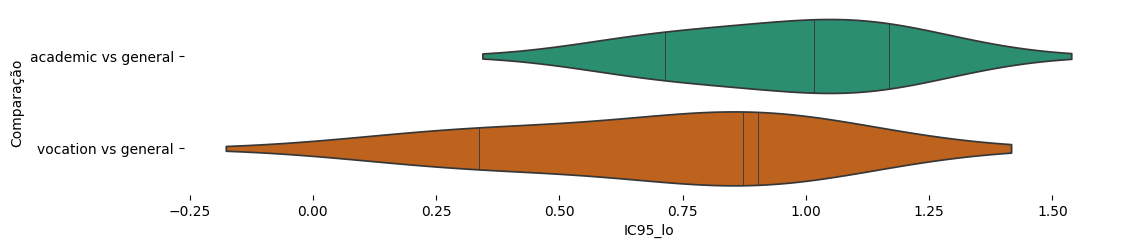

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(or_df['Comparação'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(or_df, x='IC95_lo', y='Comparação', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

### Análise e Conclusões sobre o Gráfico de Violino e o DataFrame `or_df`

O gráfico de violino gerado a partir do código nos permite visualizar a relação entre o DataFrame `or_df` e a análise. No entanto, é importante entender o que o gráfico mostra e o que ele não mostra.

#### O que o Gráfico de Violino nos Apresenta

O gráfico foi construído para visualizar a distribuição da coluna `IC95_lo` (o limite inferior do intervalo de confiança de 95%) para cada uma das comparações.

1.  **Distribuição dos Limites Inferiores**: O corpo do "violino" representa a densidade de probabilidade dos valores de `IC95_lo`. Isso nos dá uma ideia de onde os limites inferiores estão concentrados para cada comparação.
2.  **Relação Direta com o DataFrame**: O gráfico é uma representação visual direta de uma única coluna (`IC95_lo`) do DataFrame `or_df`, agrupando-a pelas categorias na coluna `Comparação`.

#### Conclusões e Limitações

Apesar de ser uma visualização interessante, o gráfico de violino para o limite inferior de confiança possui uma limitação crucial para a interpretação dos resultados do modelo.

* **Inferência Principal**: A principal inferência que podemos tirar é que a maioria dos limites inferiores para a comparação `academic vs general` é maior que os da comparação `vocation vs general`. Isso sugere que a chance de estar em um programa acadêmico (em relação ao geral) é geralmente maior do que a chance de estar em um vocacional.
* **Conclusão Incompleta**: Para determinar se um `Odds Ratio` é estatisticamente significativo, precisamos saber se o **intervalo de confiança completo** (incluindo o limite superior, `IC95_hi`) inclui o valor **1**. Como este gráfico não mostra o limite superior, **não é possível usá-lo para concluir sobre a significância estatística** dos efeitos.

Em resumo, o gráfico é útil para visualizar a distribuição dos limites inferiores de confiança, mas a análise completa e a conclusão sobre a significância dos *Odds Ratios* dependem da visualização de todo o intervalo de confiança, que só é possível ao analisar o DataFrame `or_df` completo ou usando um tipo de gráfico mais apropriado, como um gráfico de pontos de erro.

## 6) Previsões e Matriz de Confusão

/tmp/ipython-input-1707104529.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = proba.groupby(df_model["prog"]).mean()


Acurácia (in-sample): 0.610

Matriz de confusão:
 col_0     general  academic  vocation
prog                                 
general         7        27        11
academic        4        92         9
vocation        4        23        23


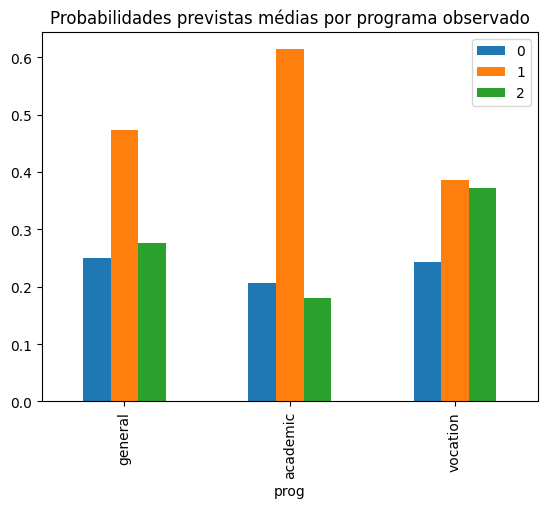

In [8]:
proba = res.predict(X)
y_pred = proba.values.argmax(axis=1)
acc = (y_pred == y.values).mean()
print(f"Acurácia (in-sample): {acc:.3f}")

conf_mat = pd.crosstab(df_model["prog"], pd.Categorical.from_codes(y_pred, df["prog"].cat.categories))
print("\nMatriz de confusão:\n", conf_mat)

# Probabilidades previstas médias
means = proba.groupby(df_model["prog"]).mean()
means.plot(kind="bar")
plt.title("Probabilidades previstas médias por programa observado")
plt.show()


## 7) VIF - Multicolinearidade

In [9]:
X_no_const = X.drop(columns=["const"])
vif = pd.DataFrame({
    "Variável": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
})
vif


,Variável,VIF
0,ses_middle,2.863767
1,ses_high,2.319347
2,write,4.183114


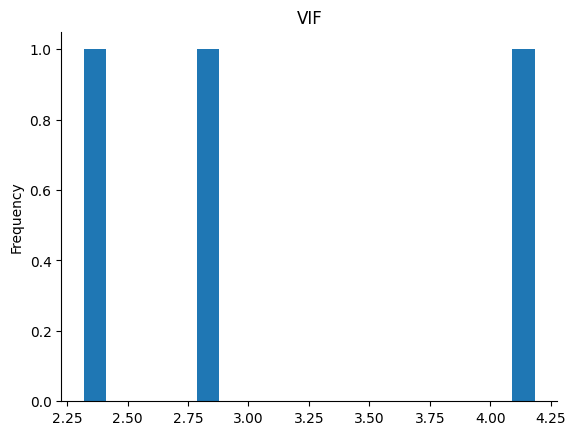

In [10]:
from matplotlib import pyplot as plt
vif['VIF'].plot(kind='hist', bins=20, title='VIF')
plt.gca().spines[['top', 'right',]].set_visible(False)

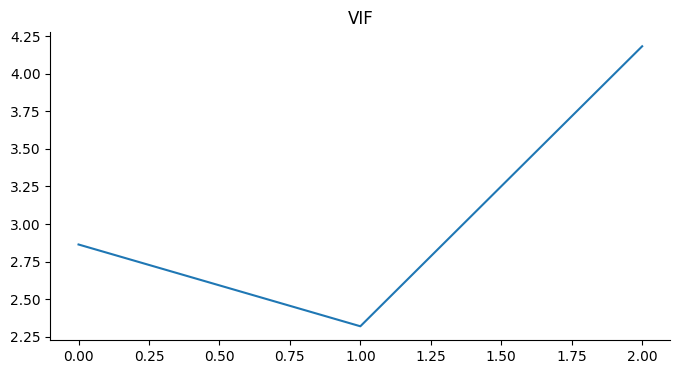

In [11]:
from matplotlib import pyplot as plt
vif['VIF'].plot(kind='line', figsize=(8, 4), title='VIF')
plt.gca().spines[['top', 'right']].set_visible(False)

In [13]:
# Recuperar categorias da variável dependente
cats = df_model["prog"].cat.categories.tolist()
# ['general', 'academic', 'vocation']

params = res.params
pvals = res.pvalues
ci = res.conf_int()

rows = []
mapping = {0: "1", 1: "2"}  # col 0 → '1' no conf_int (academic), col 1 → '2' (vocation)

for eq in params.columns:  # 0=academic vs general, 1=vocation vs general
    comp = f"{cats[eq+1]} vs {cats[0]}"
    eq_key = mapping[eq]
    for var in params.index:
        if var == "const":
            continue
        beta = params.loc[var, eq]
        lo = ci.loc[(eq_key, var), "lower"]
        hi = ci.loc[(eq_key, var), "upper"]
        p = pvals.loc[var, eq]
        rows.append([comp, var, np.exp(beta), np.exp(lo), np.exp(hi), p])

or_df = pd.DataFrame(rows, columns=["Comparação", "Variável", "OR", "IC95_lo", "IC95_hi", "p_valor"])
display(or_df)


,Comparação,Variável,OR,IC95_lo,IC95_hi,p_valor
0,academic vs general,ses_middle,1.704533,0.714332,4.067343,0.229429
1,academic vs general,ses_high,3.198980,1.167635,8.764273,0.023737
2,academic vs general,write,1.059639,1.016092,1.105053,0.006819
3,vocation vs general,ses_middle,2.281160,0.872896,5.961412,0.092451
4,vocation vs general,ses_high,1.197411,0.335952,4.267850,0.781141
5,vocation vs general,write,0.945847,0.903569,0.990104,0.017022


### Análise dos Resultados da Regressão Multinomial

O modelo de regressão multinomial foi ajustado para entender como o **status socioeconômico (`ses`)** e a **nota de escrita (`write`)** influenciam a escolha do tipo de programa escolar (**`prog`**). A análise principal se concentra em como esses fatores aumentam ou diminuem a chance de um aluno escolher um programa específico em comparação com a categoria de referência, que neste caso é o **Programa Geral (`General`)**.

---

### Comparação: Programa Acadêmico vs. Programa Geral

Esta análise nos mostra o que diferencia um aluno que escolhe o programa acadêmico daqueles que escolhem o programa geral. Os resultados indicam que:

* **Status Socioeconômico (`SES`)**: Alunos com **status socioeconômico alto (`SES High`)** têm uma chance significativamente maior de estar no programa acadêmico do que no programa geral. Em outras palavras, um alto status socioeconômico é um fator que aumenta a probabilidade de um aluno seguir uma trajetória acadêmica.
* **Nota de Escrita (`write`)**: Cada ponto adicional na nota de `write` aumenta a probabilidade de um aluno escolher o programa acadêmico em vez do programa geral. Isso significa que alunos com melhores habilidades de escrita são mais propensos a optar por programas que exigem um nível acadêmico mais elevado.

---

### Comparação: Programa Vocacional vs. Programa Geral

Aqui, o foco é entender o que leva um aluno a escolher o programa vocacional em vez do programa geral. A análise dos resultados revela que:

* **Nota de Escrita (`write`)**: Alunos com notas mais altas na prova de `write` têm uma chance reduzida de estar em um programa vocacional em comparação com o programa geral. Isso sugere que a escolha por programas vocacionais é mais comum entre alunos com notas de escrita mais baixas.
* **Status Socioeconômico (`SES`)**: Diferente da comparação anterior, o status socioeconômico **não demonstrou ter um efeito estatisticamente significativo** na escolha entre o programa vocacional e o programa geral.

Teste